# Phase 2: Predictive Modeling & Customer Insights

The objective of this phase is to build machine learning models for predicting customer churn. The dataset is preprocessed through feature engineering, encoding, and train-test splitting. Multiple classification models are trained and evaluated to identify the best-performing model. Finally, feature importance and business recommendations are provided to support customer retention and decision-making.

In [1]:
#importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix;

In [2]:
#Loading DataSets
df = pd.read_csv("Customer_churn.csv")
print("="*60)
print(df.head())
print( df.info())
print(df.shape)
print("="*60);

   CustomerID  Count        Country       State         City  Zip Code  \
0  3668-QPYBK      1  United States  California  Los Angeles     90003   
1  9237-HQITU      1  United States  California  Los Angeles     90005   
2  9305-CDSKC      1  United States  California  Los Angeles     90006   
3  7892-POOKP      1  United States  California  Los Angeles     90010   
4  0280-XJGEX      1  United States  California  Los Angeles     90015   

                 Lat Long   Latitude   Longitude  Gender  ...        Contract  \
0  33.964131, -118.272783  33.964131 -118.272783    Male  ...  Month-to-month   
1   34.059281, -118.30742  34.059281 -118.307420  Female  ...  Month-to-month   
2  34.048013, -118.293953  34.048013 -118.293953  Female  ...  Month-to-month   
3  34.062125, -118.315709  34.062125 -118.315709  Female  ...  Month-to-month   
4  34.039224, -118.266293  34.039224 -118.266293    Male  ...  Month-to-month   

  Paperless Billing             Payment Method  Monthly Charges Tota

In [3]:
#Data Processing
df["Total Charges"] = pd.to_numeric(df["Total Charges"], errors="coerce")
df.drop(columns=[
    "CustomerID",
    "Churn Label",
    "Churn Score",
    "Churn Reason",
    "Churn Category",
    "Customer Status"
], inplace=True, errors="ignore")
df.dropna(inplace=True);

In [4]:
#Feature Engineering
le = LabelEncoder()

for col in df.select_dtypes(include=["object", "string", "str"]).columns:
    df[col] = le.fit_transform(df[col].astype(str))
    X = df.drop("Churn Value", axis=1)
    y = df["Churn Value"];

In [5]:
#Spliting DataSets
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y);

In [6]:
# The Decision Tree model
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
dt_model = DecisionTreeClassifier(
    criterion='gini',     
    max_depth=5,          
    random_state=42
)

# Training the model
dt_model.fit(X_train, y_train);

In [7]:
# Testing of Decsioin Tree
y_pred_dt = dt_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred_dt)
print("="*60)
print("Decision Tree Accuracy",accuracy)
print("="*60)
print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_dt));

Decision Tree Accuracy 0.7732764747690121

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.82      0.84      1033
           1       0.57      0.64      0.60       374

    accuracy                           0.77      1407
   macro avg       0.71      0.73      0.72      1407
weighted avg       0.78      0.77      0.78      1407


Confusion Matrix:
[[849 184]
 [135 239]]


In [8]:
# Random Forest Training
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train);

In [9]:
#Random Forest Predection
prediction = model.predict(X_test)
print("="*60)
print(" Random Forest Accuracy:", accuracy_score(y_test, prediction))
print("="*60)
print("\nClassification Report:")
print(classification_report(y_test, prediction))
cm = confusion_matrix(y_test, prediction)
print("\nConfusion Matrix:")
print(cm);

 Random Forest Accuracy: 0.80593340440653873

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1033
           1       0.64      0.49      0.56       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407


Confusion Matrix:
[[928 105]
 [190 184]]


In [14]:
#Model Summary
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
shape_table = pd.DataFrame({
    "Dataset": ["Training Data", "Testing Data"],
    "Number of Customers": [X_train_scaled.shape[0], X_test_scaled.shape[0]],
    "Number of Features": [X_train_scaled.shape[1], X_test_scaled.shape[1]]
})
print("="*60)
print("Feature Scaling Summary")
print("="*60)
display(shape_table)

Feature Scaling Summary


,Dataset,Number of Customers,Number of Features
0,Training Data,5625,28
1,Testing Data,1407,28


In [11]:
# Logistic Regression 
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(max_iter=5000,random_state=42)
lr.fit(X_train_scaled, y_train)
lr_pred = lr.predict(X_test_scaled)
print("="*60)
print("Logistic Regression Accuracy:", accuracy_score(y_test, lr_pred))
print("="*60)
print("\nClassification Report:")
print(classification_report(y_test, lr_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, lr_pred));

Logistic Regression Accuracy: 0.8031201492537313

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.88      0.87      1033
           1       0.64      0.61      0.63       374

    accuracy                           0.81      1407
   macro avg       0.75      0.74      0.75      1407
weighted avg       0.80      0.81      0.80      1407


Confusion Matrix:
[[905 128]
 [145 229]]


In [12]:
#Feature Scaling Importance
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})
importance = importance.sort_values(by="Importance", ascending=False)
print(importance.head(10));

            Feature  Importance
12    Tenure Months    0.100289
26    Total Charges    0.094450
25  Monthly Charges    0.088194
22         Contract    0.072831
27             CLTV    0.066913
4          Zip Code    0.063961
3              City    0.062480
7         Longitude    0.061731
5          Lat Long    0.058764
6          Latitude    0.057370


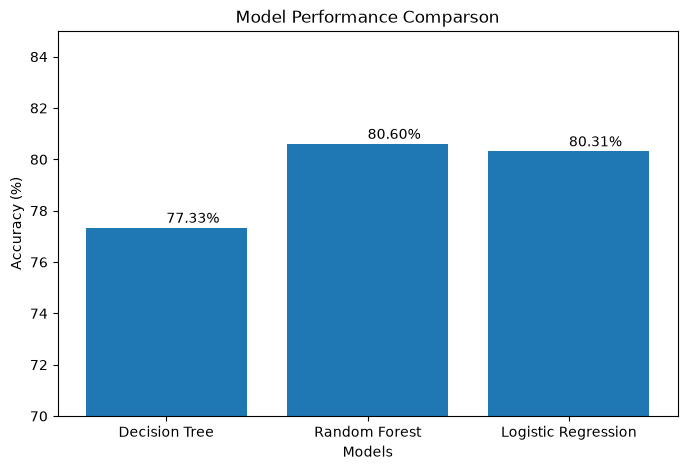

In [13]:
import matplotlib.pyplot as plt

models = ['Decision Tree', 'Random Forest', 'Logistic Regression']
accuracy = [77.33, 80.60, 80.31]

plt.figure(figsize=(8,5))
plt.bar(models, accuracy)

plt.title('Model Performance Comparson')
plt.xlabel('Models')
plt.ylabel('Accuracy (%)')

for i, v in enumerate(accuracy):
    plt.text(i, v + 0.2, f'{v:.2f}%')

plt.ylim(70, 85)
plt.show();

## Model Performance Comparison

| Model |Accuracy| Evaluation |
|--------|----------|------------|
|Decision Tree|0.7732764747690121|lower accuracy suggests it is more susceptible to overfitting and is less effective
| Random Forest | 0.8059701492537313 | High accuracy with robust performance for churn prediction. |
| Logistic Regression | 0.8031272210376688 | Good baseline model with interpretable results. |

The best-performing model can be selected based on the printed evaluation metrics.

##  Business Recommendations

- Focus retention campaigns on customers with high churn probability.
- Encourage long-term contract plans.
- Use predictive models to identify at-risk customers early.
- Personalize marketing based on customer characteristics.

##  Conclusion

Machine learning models was successfully developed to predict customer churn. Decision Tree, Random Forest and Logistic Regression were evaluated using standard classification metrics. The obtained insights and predictions can assist organizations in improving customer retention and supporting data-driven business decisions.